Choosing from all possible events


Shape: (576, 22, 1001)
Classes: {np.str_('tongue'), np.str_('right_hand'), np.str_('feet'), np.str_('left_hand')}


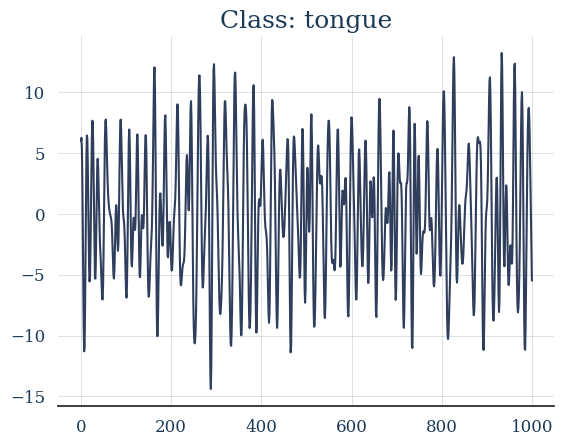

In [2]:
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
import matplotlib.pyplot as plt

dataset = BNCI2014_001()
dataset.subject_list = [1]

paradigm = MotorImagery(n_classes=4, fmin=8, fmax=30)
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])

print("Shape:", X.shape)
print("Classes:", set(y))

# TODO: 첫 trial의 첫 채널을 그려보기
plt.plot(X[0,0])
plt.title(f"Class: {y[0]}")
plt.show()

Counter({np.str_('tongue'): 144, np.str_('feet'): 144, np.str_('right_hand'): 144, np.str_('left_hand'): 144})


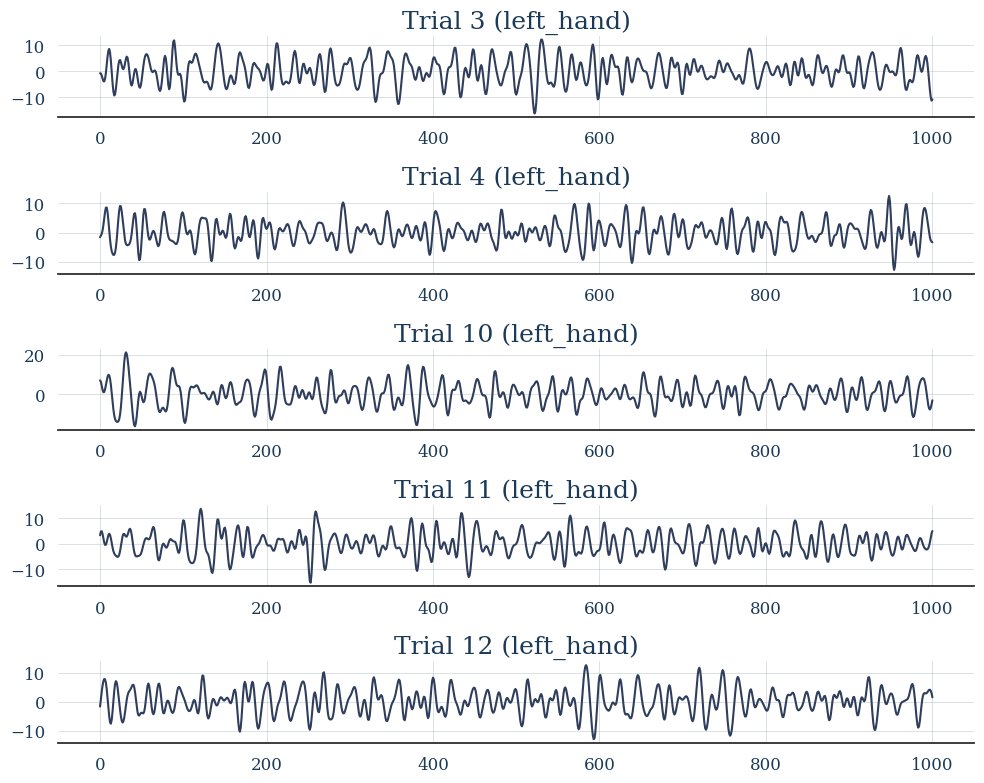

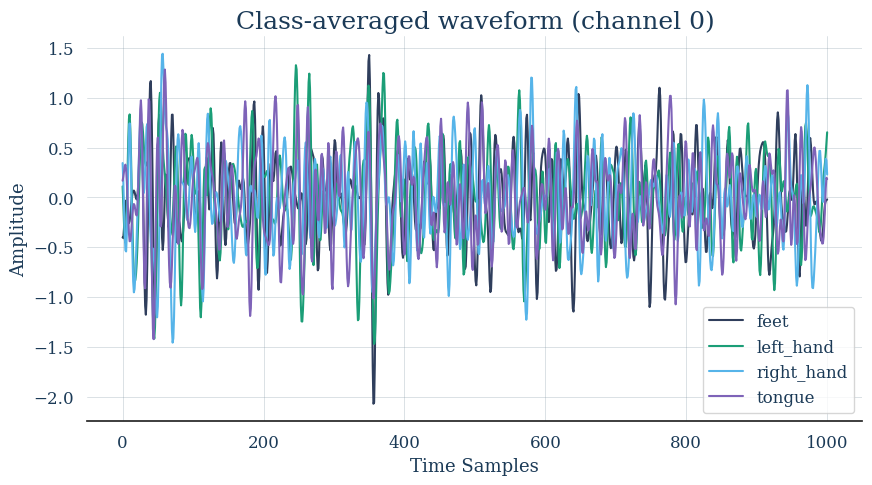

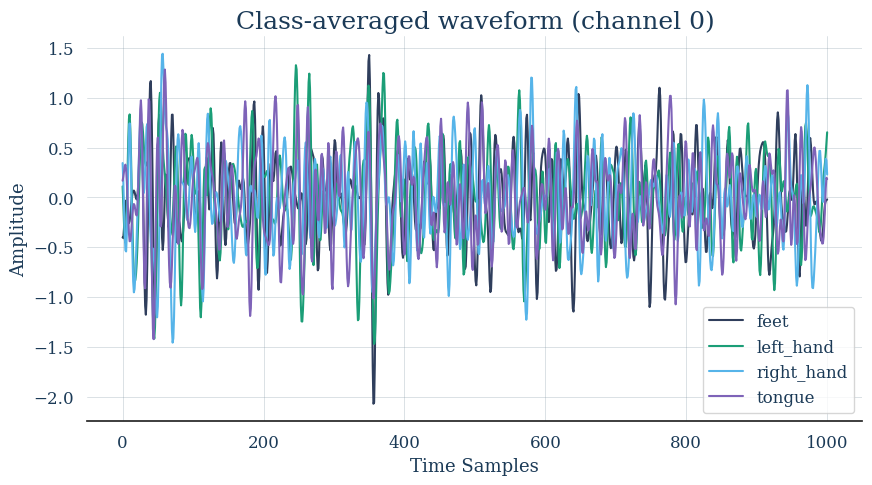

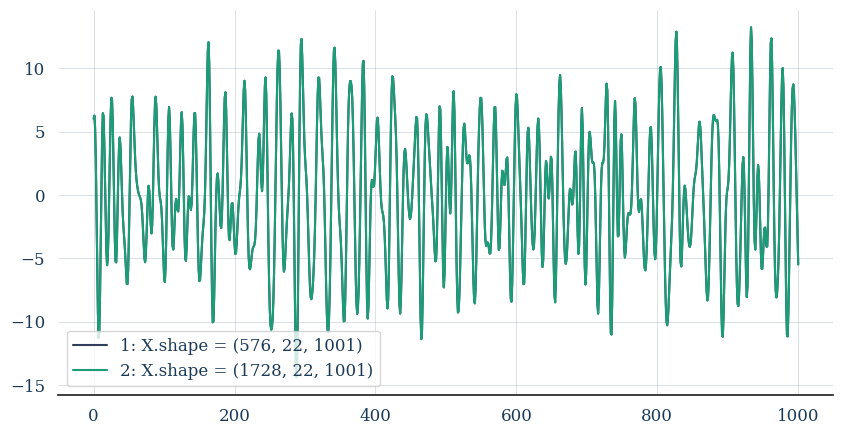

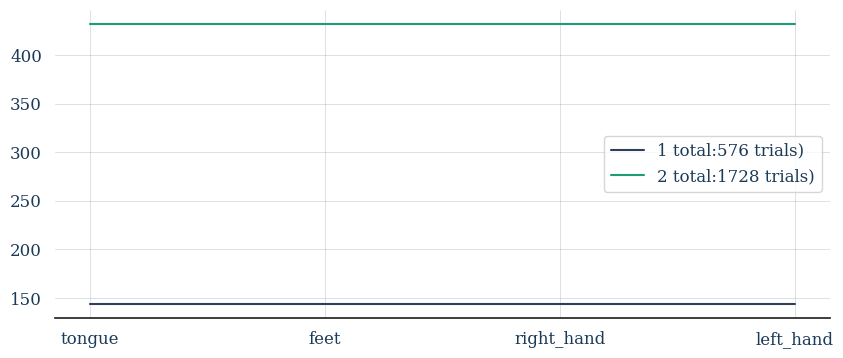

Choosing from all possible events


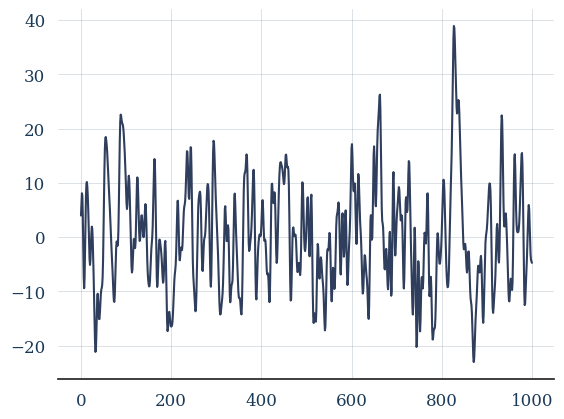

In [56]:
"""
1. `collections.Counter`로 클래스별 trial 개수 출력.
2. `left_hand` 라벨 trial 5개를 subplot으로 한 figure에 그리기.
3. 클래스별 평균 파형(채널 1개)을 그려서 차이를 눈으로 비교.
4. `subject_list=[1,2,3]`으로 늘리고 X 모양이 어떻게 변하는지 적기.
5. `fmin/fmax`를 (1,40)으로 바꿔 차이 관찰.
"""

import collections
import numpy as np

# 1. `collections.Counter`로 클래스별 trial 개수 출력.
print(collections.Counter(y))

# 2. `left_hand` 라벨 trial 5개를 subplot으로 한 figure에 그리기.
left_hand_idx = np.where(y == 'left_hand')[0]
fig, axes = plt.subplots(5, 1, figsize=[10,8])
for i, idx in enumerate(left_hand_idx[:5]):
    axes[i].plot(X[idx, 0, :])
    axes[i].set_title(f"Trial {idx} (left_hand)")
plt.tight_layout()
plt.show()

# 3. 클래스별 평균 파형(채널 1개)을 그려서 차이를 눈으로 비교.
classes = np.unique(y)
ch = 0

plt.figure(figsize=(10,5))
for cls in classes:
    idx = np.where(y == cls)[0]
    mean_wave = X[idx, ch, :].mean(axis=0)
    plt.plot(mean_wave, label=cls)
plt.legend()
plt.xlabel('Time Samples')
plt.ylabel('Amplitude')
plt.title(f'Class-averaged waveform (channel {ch})')
plt.show()

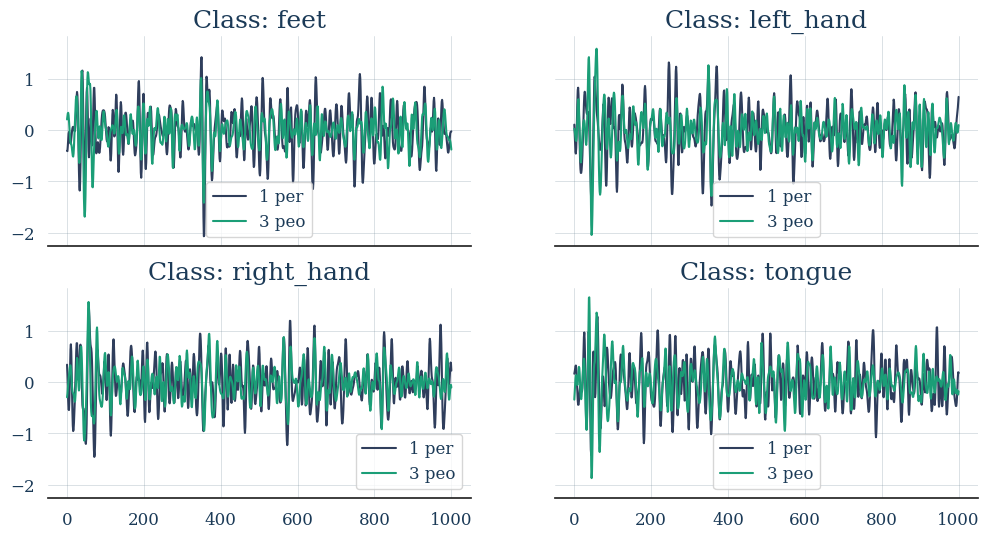

Choosing from all possible events


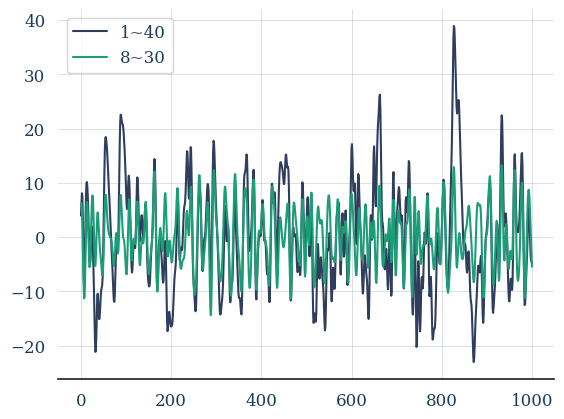

In [64]:
# 4. `subject_list=[1,2,3]`으로 늘리고 X 모양이 어떻게 변하는지 적기.
dataset2 = BNCI2014_001()
X2, y2, metadata2 = paradigm.get_data(dataset=dataset2, subjects=[1,2,3])

classes = np.unique(y)
ch = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)

for idx, cls in enumerate(classes):
    ax = axes[idx // 2, idx % 2]
    
    idx_w1 = np.where(y == cls)[0]
    mean_w1 = X[idx_w1, ch, :].mean(axis=0)

    idx_all = np.where(y2 == cls)[0]
    mean_all = X2[idx_all, ch, :].mean(axis=0)
    
    ax.plot(mean_w1, label=f'1 per')
    ax.plot(mean_all, label=f'3 peo')
    ax.set_title(f'Class: {cls}')
    ax.legend()
    
plt.show()


# 5. `fmin/fmax`를 (1,40)으로 바꿔 차이 관찰.
paradigm2 = MotorImagery(n_classes=4, fmin=1, fmax=40)
X3, y3, metadata3 = paradigm2.get_data(dataset=dataset2, subjects=[1,2,3])
plt.plot(X3[0,0], label=f'1~40')
plt.plot(X2[0,0], label=f'8~30')
plt.legend()
plt.show()